# Course Project Instructions

To be able to take the exam and complete the course, the project must have been submitted and attempted. Instructions for the project are below. The project consists of both completing the project, as well as reviewing your own submission and two submissions of other students.

The project is worth 10 points and the peer reviews are worth 5 points. Limited use of AI is allowed when working on the project (see details in the *Use of AI* section). Using AI is not allowed when doing peer reviews.

Edit history:
- 8.4 added more detailed instructions on formatting
- 21.4 clarified instructions on saving raw data 

### Documentation describing how anyone can use your Jupyter Notebook (typically placed at the very beginning) (0.5p)

What the project is about and what question it answers? 
What data source is used and how it's accessed?
What libraries are needed to run it
Any other instructions a reviewer would need

### An embedded image that describes visually the data pipeline and what happens in the notebook. Think of this like something you would use when presenting your project to e.g. a coworker or manager who does not want to see the details or code itself. (0.5p)

### Introduction (1p)

provides context and a clearly defined goal of the project (e.g. answer question X using data)

In [34]:
from dotenv import load_dotenv
import os
import requests

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data extraction (1p) with a part where the Notebook connects to an API for collecting data as the primary data source (2p)

Instructions: A component where data is extracted from some data source and/or loaded onto the Jupyter Notebook. The raw data needs to also be exported at this point and saved to the repository as a .csv or .json file, so that a reviewer can run and test the code with the saved data without needing an API key or manually loading the data from the source. E.g. have a cell where the data is exported, and a commented out code cell where the saved data can be imported.

In [2]:
#CODE: Import Armed forces personnel (% of total labor force) with the World Bank API
url_personnel ='https://api.worldbank.org/v2/country/all/indicator/MS.MIL.TOTL.TF.ZS?format=json&per_page=10000&date=1990:2024'

request_personnel = requests.get(url_personnel)
print("Status code is")
print(request_personnel.status_code)

personnel = request_personnel.json()
print(len(personnel))
print(personnel[0])

personnel_df =pd.DataFrame(personnel[1])
display(personnel_df.head())

Status code is
200
2
{'page': 1, 'pages': 1, 'per_page': 10000, 'total': 9310, 'sourceid': '2', 'lastupdated': '2026-04-08'}


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,NaN,,,1
1,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,NaN,,,1
2,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,NaN,,,1
3,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,NaN,,,1
4,"{'id': 'MS.MIL.TOTL.TF.ZS', 'value': 'Armed fo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,0.448188,,,1


In [3]:
#CODE export and save to the repository as a .csv file
personnel_df.to_csv('personnel_df.csv', index=False) 

#if needed, import the data with this line of code:
#personnel_df=pd.read_csv("personnel_df.csv")

In [4]:
#CODE import Military expenditure (% of GDP) with the World Bank API

url_expenditure ='https://api.worldbank.org/v2/country/all/indicator/MS.MIL.XPND.GD.ZS?format=json&per_page=10000&date=1990:2024'

request_expenditure = requests.get(url_expenditure)
print("Status code is")
print(request_expenditure.status_code)

expenditure = request_expenditure.json()
print(len(expenditure))
print(expenditure[0])

expenditure_df =pd.DataFrame(expenditure[1])
display(expenditure_df.head())

Status code is
200
2
{'page': 1, 'pages': 1, 'per_page': 10000, 'total': 9310, 'sourceid': '2', 'lastupdated': '2026-04-08'}


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,0.976005,,,1
1,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.044194,,,1
2,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.118534,,,1
3,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.145973,,,1
4,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,1.158166,,,1


In [5]:
#CODE export and save to the repository as a .csv file
#export and save to the repository as a .csv file
expenditure_df.to_csv('expenditure_df.csv', index=False) 

#if needed, import the data with this line of code:
#expenditure_df=pd.read_csv("expenditure_df.csv")

### A component where the loaded data is cleaned and transformed (1p)

I have two problems with the data: 
1) The indicator and country columns in the dataframes are dictionaries inside the columns. The text values need to extracted
2) The datasets contain all the countries in the world, not just NATO members. These need to be filtered to the 32 NATO members

Furthermore, the two datasets need to be merged and checked for missing values

In [6]:
#CODE: DATA CLEANING AND TRANSFORMATION
#expenditure_df
display(expenditure_df)
#The indicator and country columns in the dataframe are dictionaries inside the columns. The text values need to extracted.

expenditure_df['indicator']= expenditure_df['indicator'].apply(lambda x: x['value'])
expenditure_df['country'] = expenditure_df['country'].apply(lambda x: x['value'])

#remove indicator column because there is only one value
expenditure_df=expenditure_df.drop(["indicator"], axis=1)

#remove other redundant columns

print(expenditure_df['obs_status'].unique())
print(expenditure_df['unit'].unique())
print(expenditure_df['decimal'].unique())

expenditure_df=expenditure_df.drop(["obs_status"], axis=1)
expenditure_df=expenditure_df.drop(["unit"], axis=1)
expenditure_df=expenditure_df.drop(["decimal"], axis=1)

display(expenditure_df)

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,0.976005,,,1
1,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.044194,,,1
2,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.118534,,,1
3,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.145973,,,1
4,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,1.158166,,,1
...,...,...,...,...,...,...,...,...
9305,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1994,3.114713,,,1
9306,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1993,3.300304,,,1
9307,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1992,3.802772,,,1
9308,"{'id': 'MS.MIL.XPND.GD.ZS', 'value': 'Military...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1991,3.979365,,,1


['']
['']
[1]


,country,countryiso3code,date,value
0,Africa Eastern and Southern,AFE,2024,0.976005
1,Africa Eastern and Southern,AFE,2023,1.044194
2,Africa Eastern and Southern,AFE,2022,1.118534
3,Africa Eastern and Southern,AFE,2021,1.145973
4,Africa Eastern and Southern,AFE,2020,1.158166
...,...,...,...,...
9305,Zimbabwe,ZWE,1994,3.114713
9306,Zimbabwe,ZWE,1993,3.300304
9307,Zimbabwe,ZWE,1992,3.802772
9308,Zimbabwe,ZWE,1991,3.979365


In [7]:
#CODE: DATA CLEANING AND TRANSFORMATION
#personnel_df
#The indicator and country columns in the dataframe are dictionaries inside the columns. The text values need to extracted.

personnel_df['indicator']= personnel_df['indicator'].apply(lambda x: x['value'])
personnel_df['country'] = personnel_df['country'].apply(lambda x: x['value'])

#remove indicator column because there is only one value
personnel_df=personnel_df.drop(["indicator"], axis=1)
display(personnel_df)

#remove other redundant columns

print(personnel_df['obs_status'].unique())
print(personnel_df['unit'].unique())
print(personnel_df['decimal'].unique())

personnel_df=personnel_df.drop(["obs_status"], axis=1)
personnel_df=personnel_df.drop(["unit"], axis=1)
personnel_df=personnel_df.drop(["decimal"], axis=1)

display(personnel_df)

,country,countryiso3code,date,value,unit,obs_status,decimal
0,Africa Eastern and Southern,AFE,2024,NaN,,,1
1,Africa Eastern and Southern,AFE,2023,NaN,,,1
2,Africa Eastern and Southern,AFE,2022,NaN,,,1
3,Africa Eastern and Southern,AFE,2021,NaN,,,1
4,Africa Eastern and Southern,AFE,2020,0.448188,,,1
...,...,...,...,...,...,...,...
9305,Zimbabwe,ZWE,1994,1.107998,,,1
9306,Zimbabwe,ZWE,1993,1.246526,,,1
9307,Zimbabwe,ZWE,1992,1.259600,,,1
9308,Zimbabwe,ZWE,1991,1.211387,,,1


['']
['']
[1]


,country,countryiso3code,date,value
0,Africa Eastern and Southern,AFE,2024,NaN
1,Africa Eastern and Southern,AFE,2023,NaN
2,Africa Eastern and Southern,AFE,2022,NaN
3,Africa Eastern and Southern,AFE,2021,NaN
4,Africa Eastern and Southern,AFE,2020,0.448188
...,...,...,...,...
9305,Zimbabwe,ZWE,1994,1.107998
9306,Zimbabwe,ZWE,1993,1.246526
9307,Zimbabwe,ZWE,1992,1.259600
9308,Zimbabwe,ZWE,1991,1.211387


In [8]:
#Filter NATO members. 

# A list of NATO Country members ISO codes
nato_iso3 = [
    'ALB', 'BEL', 'BGR', 'CAN', 'HRV', 'CZE', 'DNK', 'EST', 'FIN', 'FRA',
    'DEU', 'GRC', 'HUN', 'ISL', 'ITA', 'LVA', 'LTU', 'LUX', 'MNE', 'NLD',
    'MKD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE', 'TUR',
    'GBR', 'USA'
]

personnel_NATO=personnel_df[(personnel_df['countryiso3code'].isin(nato_iso3)) ]
expenditure_NATO=expenditure_df[(expenditure_df['countryiso3code'].isin(nato_iso3)) ]

display(personnel_NATO.head())
display(expenditure_NATO.head())


,country,countryiso3code,date,value
1750,Albania,ALB,2024,NaN
1751,Albania,ALB,2023,NaN
1752,Albania,ALB,2022,NaN
1753,Albania,ALB,2021,NaN
1754,Albania,ALB,2020,0.64617


,country,countryiso3code,date,value
1750,Albania,ALB,2024,2.037862
1751,Albania,ALB,2023,1.740733
1752,Albania,ALB,2022,1.208789
1753,Albania,ALB,2021,1.242988
1754,Albania,ALB,2020,1.295836


In [17]:
#Merge the two dataframes

df= pd.merge(personnel_NATO, expenditure_NATO, on=("country","countryiso3code", "date"))


df= df.rename(columns={"value_x": "personnel", "value_y": "expenditure"})

display(df)


,country,countryiso3code,date,personnel,expenditure
0,Albania,ALB,2024,NaN,2.037862
1,Albania,ALB,2023,NaN,1.740733
2,Albania,ALB,2022,NaN,1.208789
3,Albania,ALB,2021,NaN,1.242988
4,Albania,ALB,2020,0.646170,1.295836
...,...,...,...,...,...
1115,United States,USA,1994,1.277753,4.215265
1116,United States,USA,1993,1.376005,4.604350
1117,United States,USA,1992,1.467291,4.970467
1118,United States,USA,1991,1.646722,4.883429


In [22]:
#Check for missing values
df.isna().sum()

#I decided to keep the missing values and deal with them when I analyse the data

country              0
countryiso3code      0
date                 0
personnel          172
expenditure         75
dtype: int64

### Data Analysis (2p)

A component where the cleaned data is analyzed visually and quantitatively (e.g. using statistics or machine learning)

In [21]:
#Basic statistics
df.describe()

,personnel,expenditure
count,948.000000,1045.000000
mean,1.401011,1.840523
std,1.084763,0.995532
min,0.000000,0.358492
25%,0.709071,1.291808
50%,1.064266,1.609071
75%,1.704971,2.050324
max,7.197524,11.148177


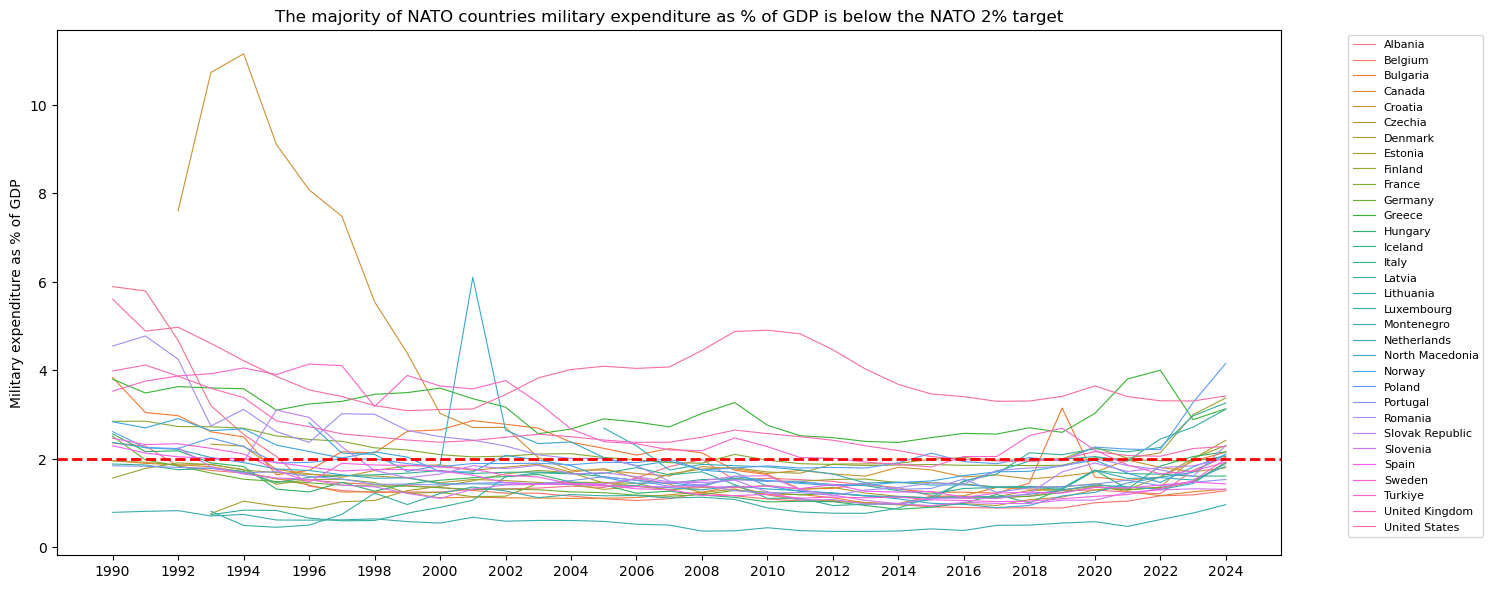

In [41]:
#Visual analysis of the data

# Line chart — spending over time for NATO members with 2% threshold line

plt.figure(figsize=(15, 6))
ax = sns.lineplot(data=df, x="date", y="expenditure", hue="country", linewidth=0.8)
ax.axhline(y=2, linewidth=2, color='red', ls='--')
ax.invert_xaxis()
ax.set_xticks(df['date'].unique()[::2])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.title("Historically, the majority of NATO countries military expenditure as % of GDP is below the NATO 2% target")
plt.ylabel("Military expenditure as % of GDP")
plt.xlabel('')
plt.show()


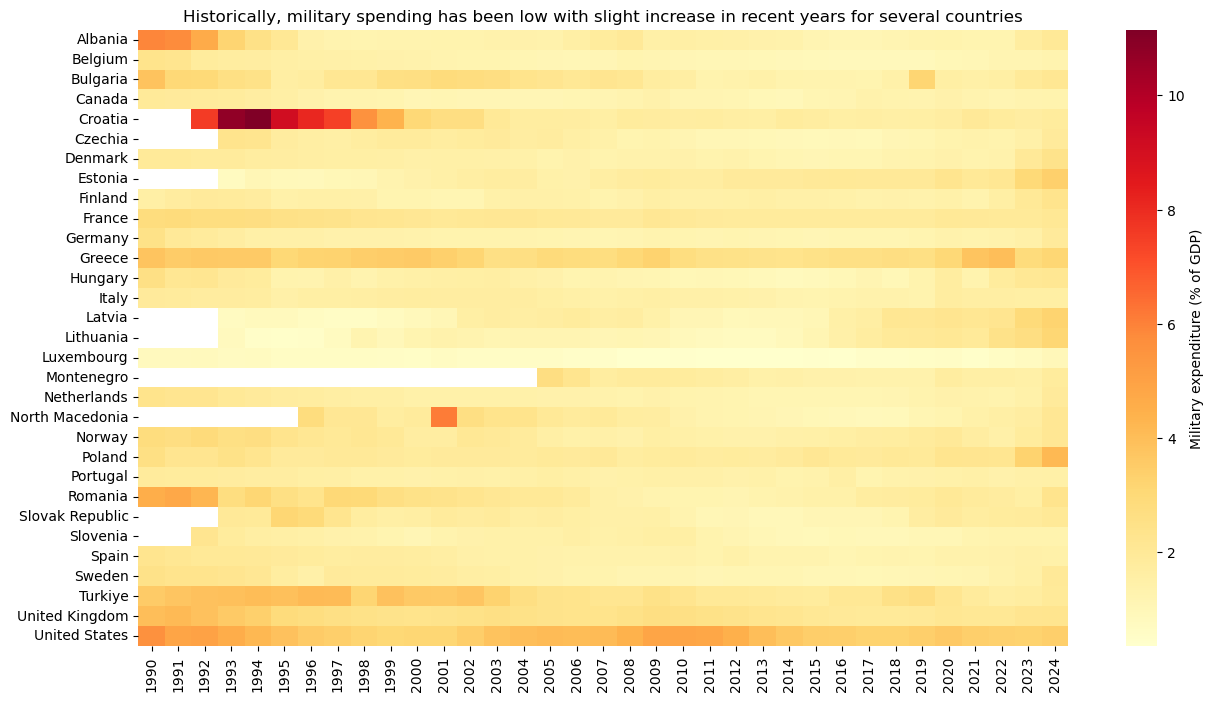

In [51]:
#Data visualisation: Heatmap
df_pivot = df.pivot_table(index='country', columns='date', values='expenditure') #convert the dataframe to wide format
#display(df_pivot)

plt.figure(figsize=(15, 8))
sns.heatmap(df_pivot, cmap='YlOrRd', cbar_kws={'label': 'Military expenditure (% of GDP)'})
plt.title("Historically, military spending has been low with slight increase in recent years for several countries")
plt.ylabel('')
plt.xlabel('')
plt.show()



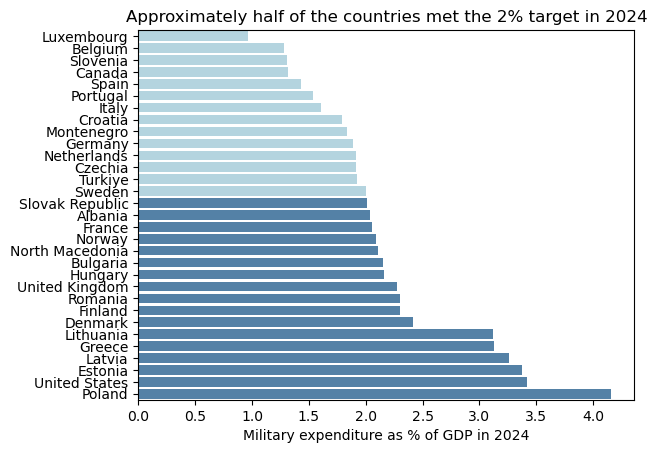

In [82]:
df_2024=df.loc[df['date'] == '2024']

df_2024=df_2024.sort_values(by=["expenditure"])
#df_2024.tail()
df_2024 = df_2024.dropna(subset=['expenditure'])

colors = ['steelblue' if x >= 2 else 'lightblue' for x in df_2024['expenditure']]
ax = sns.barplot(df_2024, x="expenditure", y="country", hue="country", palette=dict(zip(df_2024['country'], colors)), legend=False)
plt.title("Approximately half of the countries met the 2% target in 2024")
plt.ylabel('')
plt.xlabel("Military expenditure as % of GDP in 2024")
plt.show()

### Data and results exportation (1p)

A component where both the raw data and results can be exported (e.g. as a CSV)

### Cconclusions (1p)

where the most interesting results and findings are described

- The mean expenditure is 1.84% — below the 2% target, meaning on average NATO members have historically fallen short
- The 75th percentile is 2.05% — meaning only the top quarter of observations meet the target
- The max is 11.15% — someone is spending very heavily, who do you think that might be?
- Personnel has a min of 0.0 — worth investigating which country that is

The heatmap shows that most countries are pale yellow (low spending), with Croatia standing out dramatically in the 1990s, and you can see the slight warming toward the right (recent years) for several countries.

in 2024, Poland and Estonia are top performers, and Luxembourg and Belgium are the worst. The 2% line would make it instantly clear who meets the target and who doesn't.

## Submission format

The project is submitted as a standalone Jupyter Notebook that must have the following components.

## Core components

| Component | Points |
|---|---|
| An introduction that provides context and a clearly defined goal of the project (e.g. answer question X using data) | 1p |
| A component where data is extracted from some data source and/or loaded onto the Jupyter Notebook. The raw data needs to also be exported at this point and saved to the repository as a .csv or .json file, so that a reviewer can run and test the code with the saved data without needing an API key or manually loading the data from the source. E.g. have a cell where the data is exported, and a commented out code cell where the saved data can be imported. | 1p |
| A component where the loaded data is cleaned and transformed | 1p |
| A component where the cleaned data is analyzed visually and quantitatively (e.g. using statistics or machine learning) | 2p |
| A component where both the raw data and results can be exported (e.g. as a CSV) | 1p |
| A conclusion where the most interesting results and findings are described | 1p |
| **Total** | **7p** |

## Additional requirements

In addition to the previous high-level requirements, the project must also include the following elements:

| Component | Points |
|---|---|
| Documentation describing how anyone can use your Jupyter Notebook (typically placed at the very beginning) | 0.5p |
| An embedded image that describes visually the data pipeline and what happens in the notebook. Think of this like something you would use when presenting your project to e.g. a coworker or manager who does not want to see the details or code itself. | 0.5p |
| A part where the Notebook connects to an API either for collecting data as the primary data source or as a supplementary data source, or e.g. for connecting to an LLM that is used for cleaning data or analyzing data | 2p |
| **Total** | **3p** |

## Other Instructions

### Code quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between parts.
- Print out key information, using for example `df.head()`. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per part (e.g. extracting data in one cell, transforming it in another), and when relevant divide parts into multiple cells 
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

### Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title
- Colors and a legend when relevant

### Penalties

- **-5 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-5 points** if AI-generated (hallucinated) data is used instead of the actual dataset or data collected via the API. The project requires working with real data, not made-up values!
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all code for all parts is within one cell, if the relevant outcomes are difficult to understand due to too much irrelevant printed output).

Make sure to use environment variables or configuration files (excluded from version control) to store any secrets. Never hard-code API keys or passwords directly into your notebook.

### Use of AI

You are allowed to use AI to help with the project e.g., for troubleshooting, writing individual lines of code or cleaning and or improving existing code. You are not allowed to generate the entire project using AI. If you are suspected of having used AI to generate most of the project, you will be invited to a meeting to discuss the project and if you fail to explain reasonably the use of AI, you risk being removed from the entire course.

Use of AI is also not allowed during the peer review. The entire point of the peer review phase is to introduce you to reviewing code written by others! Moreover, your fellow students do not want to read AI generated feedback. **If your peer reviews are flagged as AI generated, you risk losing 5 points as a penalty.**

### Statement of AI use

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the project. This could be a markdown cell with a couple of sentences, or even a link to the chat(s).